# M4 | Research Investigation Notebook

In this notebook, you will do a research investigation of your chosen dataset in teams. You will begin by formally selecting your research question (task 0), then processing your data (task 1), creating a predictive model (task 2), evaluating your model's results (task 3), and describing the contributions of each team member (task 4).

For grading, please make sure your notebook has all cells already run. You will also need to write a short, 2 page report about your design decisions as a team, to be uploaded to Moodle in the form of a PDF file next to this Jupyter notebook.

You should provide arguments and justifications for all of your design decisions throughout this investigation. You can use your M3 responses as the basis for this discussion.

In [2]:
# Import the tables of the data set as dataframes.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = './data' # You many change the directory

# Other main package imports
import seaborn as sns
import scipy as sc

# Scikit-learn package imports
from sklearn import feature_extraction, model_selection
from sklearn.metrics import root_mean_squared_error, mean_squared_error, roc_auc_score

# PyBKT package imports
import random
old_randint = random.randint
random.randint = lambda a, b: old_randint(a, int(b))
from pyBKT.models import Model
random.randint = old_randint

## Task 0: Research Question

**Research question:**
*How does AI model usage by students affect their learning?*

## Task 1: Data Preprocessing

In this section, you are asked to preprocess your data in a way that is relevant for the model. Please include 1-2 visualizations of features / data explorations that are related to your downstream prediction task.

In [14]:
# 1. Map Gymitrainer data to rest of tables 
gymitrainer_df = pd.read_csv("/home/mlbd-project/data/gymitrainer.csv")
gymitrainer_df = gymitrainer_df.drop(columns=['chat_profile'])
#display(gymitrainer_df.head())
mapping_df = pd.read_csv("/home/mlbd-project/data/mapping.csv")
#display(mapping_df.head())

threshold = 0.5
filtered_mapping = mapping_df[mapping_df['confidence'] >= threshold]

# Contains only users where the matching is confident enough and who 
# used the chatbot at all (since they appear in gymitrainer.csv)
# Inner merging guarantees that we only have people who used the chatbot
matched_gymitrainer = pd.merge(
    gymitrainer_df,
    filtered_mapping[['id', 'user_id']],
    on='id',
    how='inner'  
)

tag_replacements = {
    'Mathehilfe': 'Mathe',
    'math_help': 'Mathe',
    'essay_writing': 'Aufsatz',
    'Aufsatzhilfe': 'Aufsatz',
    'Sprachprufung': 'Sprache',
    'text_comprehension': 'Sprache'
}

matched_gymitrainer['tag'] = matched_gymitrainer['tag'].replace(tag_replacements)

def fill_missing_tag(row):
    if pd.isna(row['tag']) or row['tag'] == '':
        content = str(row['content'])
        if content.startswith("['Hallo! Ich bin Gymitrainer, dein Mathe-Tutor") or \
           content.startswith("['Hallo! Mein Name ist Gymitrainer, und ich bin dein Mathe-Guru"):
            return 'Mathe'
        elif content.startswith("['Hey! Ich bin Gymitrainer, dein Experte für Gymi-Prüfungsaufsätze"):
            return 'Aufsatz'
        else:
            return row['tag']
    else:
        return row['tag']

matched_gymitrainer['tag'] = matched_gymitrainer.apply(fill_missing_tag, axis=1)

matched_gymitrainer = matched_gymitrainer.sort_values(by='user_id')
display(matched_gymitrainer.head())   



# 2. Remove potential teachers from the dataset as a safety 
# (we only want to study learning on students)
teachers = pd.read_csv("/home/mlbd-project/data/teachers.csv")
teacher_ids = teachers['user_id'].unique()
matched_gymitrainer = matched_gymitrainer[~matched_gymitrainer['user_id'].isin(teacher_ids)].copy()



# 3. Clean and prepare the datasets by subjects 
math_results = pd.read_csv("/home/mlbd-project/data/math_results.csv")
math_questions_clean = pd.read_csv("/home/mlbd-project/data/math_questions_clean.csv")
math_results['question'] = math_results['question'].astype(str)
math_questions_clean['question_id'] = math_questions_clean['question_id'].astype(str)
math_results_clean = math_results[
    math_results['question'].isin(math_questions_clean['question_id'])
] 
math_results_clean = math_results_clean.merge(
    math_questions_clean[['question_id', 'skill_id']],
    left_on='question',
    right_on='question_id',
    how='left'
)
math_results_clean = math_results_clean.drop(columns=['question_id'])
#math_results_clean['timestamp'] = pd.to_datetime(math_results_clean['time'], unit='s')
math_results_clean['timestamp'] = math_results_clean['time'].astype(int)
math_results_clean['correct'] = math_results_clean['correct'].astype(int)
math_results_clean['hint_used'] = (math_results_clean['hint_count'] > 0).astype(int)

# essay_results = pd.read_csv("/home/mlbd-project/data/essay_results.csv")
# essay_results_clean = essay_results.copy()
# essay_results_clean['timestamp'] = pd.to_datetime(essay_results_clean['time'], unit='s')
# essay_skill_columns = [col for col in essay_results.columns if '-' in col or col.startswith('content') or col.startswith('structure') or col.startswith('language')]
# essay_results_clean['skill_score'] = essay_results_clean[essay_skill_columns].mean(axis=1)
# essay_results_clean['correct'] = (essay_results_clean['skill_score'] >= 6).astype(int)
# essay_results_clean['skill_id'] = essay_results_clean['textType']  # Treat textType (e.g. "erzaehlung") as a skill

# text_results = pd.read_csv("/home/mlbd-project/data/text_results.csv")
# text_results_clean = text_results.copy()
# text_results_clean['timestamp'] = pd.to_datetime(text_results_clean['time'], unit='s')
# text_results_clean['skill_id'] = text_results_clean['exam_id'].astype(str) + '-' + text_results_clean['question'].astype(str)
# text_results_clean['correct'] = (text_results_clean['points'] / text_results_clean['max_points']) >= 0.5
# text_results_clean['correct'] = text_results_clean['correct'].astype(int) 

math_data = math_results_clean[['user_id', 'skill_id', 'correct', 'timestamp', 'hint_used']]
# essay_data = essay_results_clean[['user_id', 'skill_id', 'correct', 'timestamp']]
# text_data = text_results_clean[['user_id', 'skill_id', 'correct', 'timestamp']]

# essay_data.loc[:, 'hint_used'] = 0
# text_data.loc[:, 'hint_used'] = 0



# 4. Define AI usage for each user, by subject (a heavy AI user in Essays might not be a heavy AI 
# user in Math, and the criteria shall not be the same as users send many more messages on average
# to Gymitrainer for Math than for other subjects)
subject_tags = ['Mathe', 'Aufsatz', 'Sprache']

ai_usage_per_subject = matched_gymitrainer[matched_gymitrainer['tag'].isin(subject_tags)].groupby(['user_id', 'tag']).size().unstack(fill_value=0)

for subject in subject_tags:
    if subject not in ai_usage_per_subject.columns:
        ai_usage_per_subject[subject] = 0

print("# of Messages for each User, by Subject", ai_usage_per_subject.head())

def compute_threshold(series, percentile=75):
    non_zero = series[series > 0]
    return np.percentile(non_zero, percentile) if len(non_zero) > 0 else 0

def categorize_usage(count, threshold):
    if count == 0:
        return 'non_ai_user'
    elif count <= threshold:
        return 'light_ai_user'
    else:
        return 'heavy_ai_user'

cutoff_percentile = 75

for subject in subject_tags:
    threshold = compute_threshold(ai_usage_per_subject[subject], percentile=cutoff_percentile)
    ai_usage_per_subject[f'{subject}_ai_usage_category'] = ai_usage_per_subject[subject].apply(
        lambda x: categorize_usage(x, threshold)
    )

print("# of Messages for each User, by Subject", ai_usage_per_subject[[f'{s}_ai_usage_category' for s in subject_tags]].head())



# 5. Create dataframes that contain info on a user's AI usage
math_data_with_ai = math_data.merge(
    ai_usage_per_subject[['Mathe', 'Mathe_ai_usage_category']], 
    on='user_id', 
    how='left'
)

# essay_data_with_ai = essay_data.merge(
#     ai_usage_per_subject[['Aufsatz', 'Aufsatz_ai_usage_category']], 
#     on='user_id', 
#     how='left'
# )

# text_data_with_ai = text_data.merge(
#     ai_usage_per_subject[['Sprache', 'Sprache_ai_usage_category']], 
#     on='user_id', 
#     how='left'
# )

math_data_with_ai['Mathe'] = math_data_with_ai['Mathe'].fillna(0)
math_data_with_ai['Mathe_ai_usage_category'] = math_data_with_ai['Mathe_ai_usage_category'].fillna('non_ai_user')

# essay_data_with_ai['Aufsatz'] = essay_data_with_ai['Aufsatz'].fillna(0)
# essay_data_with_ai['Aufsatz_ai_usage_category'] = essay_data_with_ai['Aufsatz_ai_usage_category'].fillna('non_ai_user')

# text_data_with_ai['Sprache'] = text_data_with_ai['Sprache'].fillna(0)
# text_data_with_ai['Sprache_ai_usage_category'] = text_data_with_ai['Sprache_ai_usage_category'].fillna('non_ai_user')

math_data_categorical = math_data_with_ai.sort_values(
    by=['user_id', 'timestamp'],
    ascending=[True, True]
).reset_index(drop=True)

# essay_data_categorical = essay_data_with_ai.sort_values(
#     by=['user_id', 'timestamp'],
#     ascending=[True, True]
# ).reset_index(drop=True)

# text_data_categorical = text_data_with_ai.sort_values(
#     by=['user_id', 'timestamp'],
#     ascending=[True, True]
# ).reset_index(drop=True)



# 6. Add order_id column that orders a user-id's submissions by skill and time
math_data_categorical['order_id'] = math_data_categorical.groupby('user_id').cumcount() + 1
# essay_data_categorical['order_id'] = essay_data_categorical.groupby('user_id').cumcount() + 1
# text_data_categorical['order_id'] = text_data_categorical.groupby('user_id').cumcount() + 1



# 7. Extra columns added to use for AFM/PFA
def preprocess_data(data):
    data = data.copy()  # Avoid modifying a slice of the original DataFrame
    data.loc[:, 'aux'] = 1
    data.loc[:, 'prev_attempts'] = data.sort_values('order_id').groupby(['user_id', 'skill_id'])['aux'].cumsum() - 1

    # Number of correct and incorrect attempts before current attempt
    data.loc[:, 'correct_aux'] = data.sort_values('order_id').groupby(['user_id', 'skill_id'])['correct'].cumsum()
    data.loc[:, 'before_correct_num'] = data.sort_values('order_id').groupby(['user_id', 'skill_id'])['correct_aux'].shift(periods=1, fill_value=0)
    data.loc[:, 'before_wrong_num'] = data['prev_attempts'] - data['before_correct_num']
    return data

math_data_categorical = preprocess_data(math_data_categorical)
# essay_data_categorical = preprocess_data(essay_data_categorical)
# text_data_categorical = preprocess_data(text_data_categorical)



# 7. Visualizations

print("Math data example:")
display(math_data_categorical.head(30))

# print("Essay data example:")
# display(essay_data_categorical.head())

# print("Text data example:")
# display(text_data_categorical.head())



# 8. Datasets cut by AI Usage for training

df_non_ai_math = math_data_categorical[math_data_categorical['Mathe_ai_usage_category'] == 'non_ai_user'].drop(columns='Mathe_ai_usage_category')
df_light_ai_math = math_data_categorical[math_data_categorical['Mathe_ai_usage_category'] == 'light_ai_user'].drop(columns='Mathe_ai_usage_category')
df_heavy_ai_math = math_data_categorical[math_data_categorical['Mathe_ai_usage_category'] == 'heavy_ai_user'].drop(columns='Mathe_ai_usage_category')

# df_non_ai_essay = essay_data_categorical[essay_data_categorical['ai_usage_category'] == 'non_ai_user'].drop(columns='ai_usage_category')
# df_light_ai_essay = essay_data_categorical[essay_data_categorical['ai_usage_category'] == 'light_ai_user'].drop(columns='ai_usage_category')
# df_heavy_ai_essay = essay_data_categorical[essay_data_categorical['ai_usage_category'] == 'heavy_ai_user'].drop(columns='ai_usage_category')

# df_non_ai_text = text_data_categorical[text_data_categorical['ai_usage_category'] == 'non_ai_user'].drop(columns='ai_usage_category')
# df_light_ai_text = text_data_categorical[text_data_categorical['ai_usage_category'] == 'light_ai_user'].drop(columns='ai_usage_category')
# df_heavy_ai_text = text_data_categorical[text_data_categorical['ai_usage_category'] == 'heavy_ai_user'].drop(columns='ai_usage_category')

display(df_non_ai_math.head(30))

,Unnamed: 0,id,tag,message_count,startTime,endTime,content,user_id
1630,4454,321dae4e-6d92-40be-b780-232cecf3b586,NaN,1,1730219336,1730219336,['wie soll ich das rechnen'],4
1629,4453,74677c94-340b-4017-9cba-5d38cd1bf581,Aufsatz,3,1730219315,1730220391,"[""Hey! Ich bin Gymitrainer, dein Experte für G...",4
305,772,109cbf59-7ca4-49d7-9879-40d79e666557,Aufsatz,2,1738769310,1738769622,"[""Hey! Ich bin Gymitrainer, dein Experte für G...",6
313,803,bf6c477d-578b-4234-9126-636c64fc09a4,Mathe,3,1738678028,1738681716,"['Hallo! Ich bin Gymitrainer, dein Mathe-Tutor...",6
526,1443,6923b14e-55b3-4aee-8d9c-fd5305295cb2,Mathe,1,1736181505,1736184444,"['Hallo! Ich bin Gymitrainer, dein Mathe-Tutor...",6


# of Messages for each User, by Subject tag      Aufsatz  Mathe  Sprache
user_id                         
4              1      0        0
6              2      7        0
7              0      2        0
9              0      4        0
11             0      3        0
# of Messages for each User, by Subject tag     Mathe_ai_usage_category Aufsatz_ai_usage_category  \
user_id                                                     
4                   non_ai_user             light_ai_user   
6                 heavy_ai_user             light_ai_user   
7                 light_ai_user               non_ai_user   
9                 light_ai_user               non_ai_user   
11                light_ai_user               non_ai_user   

tag     Sprache_ai_usage_category  
user_id                            
4                     non_ai_user  
6                     non_ai_user  
7                     non_ai_user  
9                     non_ai_user  
11                    non_ai_user  
Math data

,user_id,skill_id,correct,timestamp,hint_used,Mathe,Mathe_ai_usage_category,order_id,aux,prev_attempts,correct_aux,before_correct_num,before_wrong_num
0,1,Textaufgaben,0,1730512029,0,0.00000,non_ai_user,1,1,0,0,0,0
1,1,Textaufgaben,1,1730512029,0,0.00000,non_ai_user,2,1,1,1,0,1
2,1,Textaufgaben,0,1730512029,0,0.00000,non_ai_user,3,1,2,1,1,1
3,1,Textaufgaben,1,1730512029,0,0.00000,non_ai_user,4,1,3,2,1,2
4,1,Zahlen und Arithmetik,1,1730512029,0,0.00000,non_ai_user,5,1,0,1,0,0
5,1,Zahlen und Arithmetik,1,1730512029,0,0.00000,non_ai_user,6,1,1,2,1,0
6,1,Textaufgaben,0,1730512029,0,0.00000,non_ai_user,7,1,4,2,2,2
7,1,Textaufgaben,1,1730512029,0,0.00000,non_ai_user,8,1,5,3,2,3
8,1,Textaufgaben,1,1730512029,0,0.00000,non_ai_user,9,1,6,4,3,3
9,1,Textaufgaben,0,1730512029,0,0.00000,non_ai_user,10,1,7,4,4,3


,user_id,skill_id,correct,timestamp,hint_used,Mathe,order_id,aux,prev_attempts,correct_aux,before_correct_num,before_wrong_num
0,1,Textaufgaben,0,1730512029,0,0.00000,1,1,0,0,0,0
1,1,Textaufgaben,1,1730512029,0,0.00000,2,1,1,1,0,1
2,1,Textaufgaben,0,1730512029,0,0.00000,3,1,2,1,1,1
3,1,Textaufgaben,1,1730512029,0,0.00000,4,1,3,2,1,2
4,1,Zahlen und Arithmetik,1,1730512029,0,0.00000,5,1,0,1,0,0
5,1,Zahlen und Arithmetik,1,1730512029,0,0.00000,6,1,1,2,1,0
6,1,Textaufgaben,0,1730512029,0,0.00000,7,1,4,2,2,2
7,1,Textaufgaben,1,1730512029,0,0.00000,8,1,5,3,2,3
8,1,Textaufgaben,1,1730512029,0,0.00000,9,1,6,4,3,3
9,1,Textaufgaben,0,1730512029,0,0.00000,10,1,7,4,4,3


The preprocessing pipeline above is designed to clean, align, and annotate data relative to student learning behavior, AI tutor interactions, and task performance, in preparation for downstream modeling using Knowledge Tracing (KT) approaches — specifically BKT and AFM/PFA. The goal is to enable the analysis of student performance across time and skill domains as a function of AI usage, in order to assess the effectiveness of the Gymitrainer AI model.


The dataset gymitrainer.csv contains logs of AI tutor interactions with users but uses a different identifier format from the user_id used in the rest of the platform’s data. To align these, we used mapping.csv, which provides a timestamp-based mapping with associated confidence scores.
We applied a confidence threshold of 0.5 to retain only reliable mappings, and performed an inner join between gymitrainer.csv and the filtered mapping. This ensured that the resulting data only included verified student interactions with the AI tutor.


Each AI interaction is labeled with a tag indicating its subject domain. We standardized these labels by mapping inconsistent entries (e.g, Mathehilfe, essay_writing) to a consistent set: Mathe (math), Aufsatz (essay), Sprache (text comprehension), and Gespräch (voice-based interactions).
For interactions with missing tags, we inferred the subject domain by analyzing the AI’s introduction messages and mapping the interaction to the correct subject. This step ensured that each interaction was properly assigned to a subject or excluded from analysis when irrelevant.


To focus exclusively on student learning behavior, we removed all entries where the user_id appeared in teachers.csv. This eliminated any potential interference from teachers experimenting with the platform.


The original math_questions.csv was enriched with a skill_id column to enable KT modeling. Rather than assigning each question_id a unique skill — which would result in sparse and uninformative practice patterns — we grouped similar questions under broader skill categories.
Using ChatGPT by giving it math_questions.csv and explaning to it GoGymi platform’s curriculum structure, we classified questions into three high-level skill domains: Zahlen und Arithmetik (direct arithmetic and computation tasks), Textaufgaben (applied word problems involving context or units) and Geometrie (geometry-based tasks).
This design balances generalization and fidelity by reducing misclassification risk while preserving topic-level granularity. The resulting dataset is saved as math_questions_clean.csv.

Each entry in math_results.csv was linked to a skill_id using the classification in math_questions_clean.csv. We removed entries with invalid or unclassifiable questions.
The resulting math_data dataset includes: skill_id (curriculum-aligned skill label), correct (binary correctness (0/1) directly taken from the original dataset), hint_used (whether a hint was used (derived from hint_count)) and timestamp (time column in the original dataset).


Using the cleaned Gymitrainer interactions, we computed subject-specific AI usage per student:
The number of AI messages was counted for each user in each subject (Mathe, Aufsatz, Sprache). A 75th percentile threshold was used to define usage categories: non_ai_user (0 messages), light_ai_user (1 to threshold) and heavy_ai_user (above threshold). This normalization accounts for differing AI usage patterns across subjects. The resulting categories (e.g, Mathe_ai_usage_category) were merged into the subject-specific learning datasets.
Missing values (e.g, users who never used the AI) were filled as 0 messages and labeled as non_ai_user.

The math_data was sorted first by user_id and then by timestamp to ensure the temporal ordering of student attempts. This is essential for any sequential modeling approach such as BKT, AFM, or PFA.

We created the following features used in AFM and PFA models: prev_attempts (number of prior attempts by a student on the same skill), before_correct_num (number of successful attempts before the current one), before_wrong_num (number of failed attempts before the current one).
These features allow models to estimate how practice and correctness history influence future performance.


The same preprocessing pipeline was scaffolded (and partially implemented) for Essay writing (essay_data_categorical) and Text comprehension (text_data_categorical).
While these were commented out in the current code for clarity, they follow the same structure and are ready for full integration. This design ensures scalability of the KT analysis across all subject areas.


The final subject-specific datasets (e.g., math_data_categorical) are now clean, chronologically ordered, and enriched with curriculum-aligned skills, AI usage metadata, and practice history features. These dataframes are now ready for direct input into KT models to assess learning outcomes under different AI usage patterns.

## Task 2: Model Building

Train a model for your research question. 

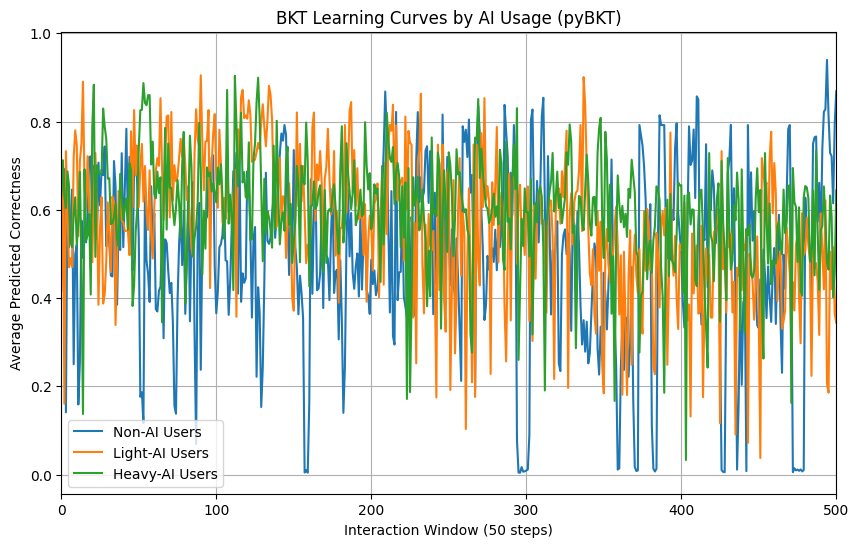

In [3]:
from pyBKT.models import Model
import pandas as pd

def prepare_pyBKT_format(df, user_col='user_id', skill_col='skill_id', correct_col='correct'):
    """Prepare data for pyBKT format"""
    data = df[[user_col, skill_col, correct_col]].copy()
    data.columns = ['user_id', 'skill_name', 'correct']
    return data

# Filter all_data_categorical to only contain skills that are observed enough 
# (i.e. at least 50 interactions with the skills)
skill_counts = all_data_categorical['skill_id'].value_counts()
valid_skills = skill_counts[skill_counts >= 50].index.tolist()
all_data_categorical = all_data_categorical[all_data_categorical['skill_id'].isin(valid_skills)]

non_ai_users = all_data_categorical[all_data_categorical['ai_usage_category'] == 'non_ai_user']
light_ai_users = all_data_categorical[all_data_categorical['ai_usage_category'] == 'light_ai_user']
heavy_ai_users = all_data_categorical[all_data_categorical['ai_usage_category'] == 'heavy_ai_user']

non_ai_data = prepare_pyBKT_format(non_ai_users)
light_ai_data = prepare_pyBKT_format(light_ai_users)
heavy_ai_data = prepare_pyBKT_format(heavy_ai_users)

def train_bkt(df):
    model = Model(seed=42)  # reproducible results
    model.fit(data=df)
    return model

bkt_non_ai = train_bkt(non_ai_data)
bkt_light_ai = train_bkt(light_ai_data)
bkt_heavy_ai = train_bkt(heavy_ai_data)

import matplotlib.pyplot as plt
import numpy as np

def predict_learning_curve(model, df, label):
    preds = model.predict(data=df)
    preds_correct = preds['correct_predictions']
    
    avg_correct = []
    window = 10
    preds_correct = preds_correct.tolist()
    
    for i in range(0, len(preds_correct), window):
        avg_correct.append(np.mean(preds_correct[i:i+window]))
    return avg_correct

non_ai_curve = predict_learning_curve(bkt_non_ai, non_ai_data, 'Non-AI Users')
light_ai_curve = predict_learning_curve(bkt_light_ai, light_ai_data, 'Light-AI Users')
heavy_ai_curve = predict_learning_curve(bkt_heavy_ai, heavy_ai_data, 'Heavy-AI Users')

# Plot
plt.figure(figsize=(10,6))
plt.plot(non_ai_curve, label='Non-AI Users')
plt.plot(light_ai_curve, label='Light-AI Users')
plt.plot(heavy_ai_curve, label='Heavy-AI Users')
plt.title('BKT Learning Curves by AI Usage (pyBKT)')
plt.xlabel('Interaction Window (50 steps)')
plt.ylabel('Average Predicted Correctness')
plt.xlim(0, 500)
plt.grid()
plt.legend()
plt.show()

*Your discussion about your model training goes here*

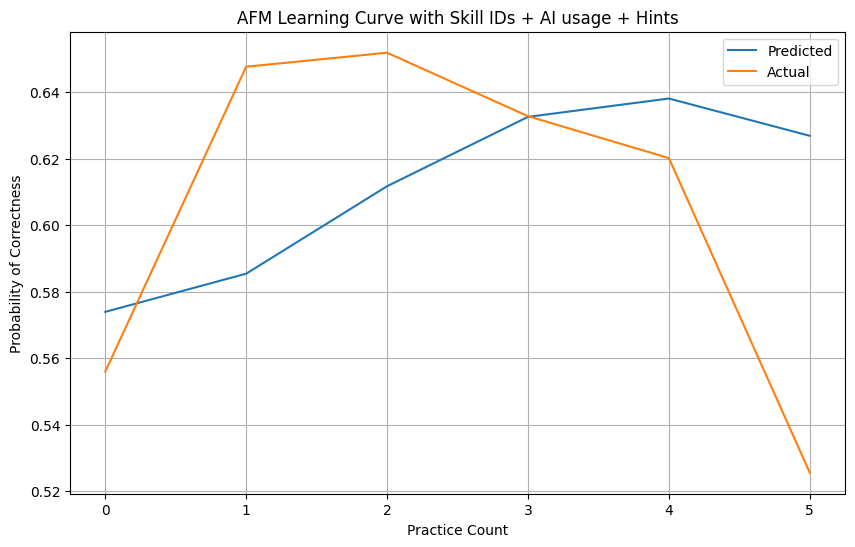

practice_count
0     39876
1     10920
2      4160
3      1664
4       861
5       451
6       230
7       137
8       114
9        70
10       47
11       42
12       40
13       27
14       26
15       23
16       22
17       16
18       14
19       12
20       10
21        9
22        7
23        4
24        3
25        2
26        1
27        1
28        1
29        1
30        1
Name: count, dtype: int64


In [6]:
#AFM
from sklearn.linear_model import LogisticRegression

def prepare_afm_features(df):
    """Prepare features for AFM modeling."""
    df = df.copy()
    df = df.sort_values(['user_id', 'timestamp'])
    df['practice_count'] = df.groupby(['user_id', 'skill_id']).cumcount()
    
    if 'hint_used' not in df.columns:
        df['hint_used'] = 0  # No hints for essay
    if 'ai_message_count' not in df.columns:
        df['ai_message_count'] = 0
    
    features = df[['practice_count', 'hint_used', 'ai_message_count', 'skill_id']].copy()
    X = pd.get_dummies(features, columns=['skill_id'])  # One-hot encode skill
    y = df['correct']
    
    return X, y

X_afm, y_afm = prepare_afm_features(all_data_categorical)

afm_model = LogisticRegression(max_iter=1000)
afm_model.fit(X_afm, y_afm)

y_pred_probs = afm_model.predict_proba(X_afm)[:,1]

def plot_learning_curve(X, y_true, y_pred_probs, title="AFM Learning Curve"):
    df_plot = X.copy()
    df_plot['true'] = y_true
    df_plot['pred'] = y_pred_probs
    df_plot = df_plot[df_plot['practice_count'] <= 5]
    
    avg_pred = df_plot.groupby('practice_count')['pred'].mean()
    avg_true = df_plot.groupby('practice_count')['true'].mean()

    plt.figure(figsize=(10,6))
    plt.plot(avg_pred.index, avg_pred.values, label='Predicted')
    plt.plot(avg_true.index, avg_true.values, label='Actual')
    plt.title(title)
    plt.xlabel('Practice Count')
    plt.ylabel('Probability of Correctness')
    plt.grid()
    plt.legend()
    plt.show()

plot_learning_curve(X_afm, y_afm, y_pred_probs, title="AFM Learning Curve with Skill IDs + AI usage + Hints")

print(X_afm['practice_count'].value_counts().sort_index())

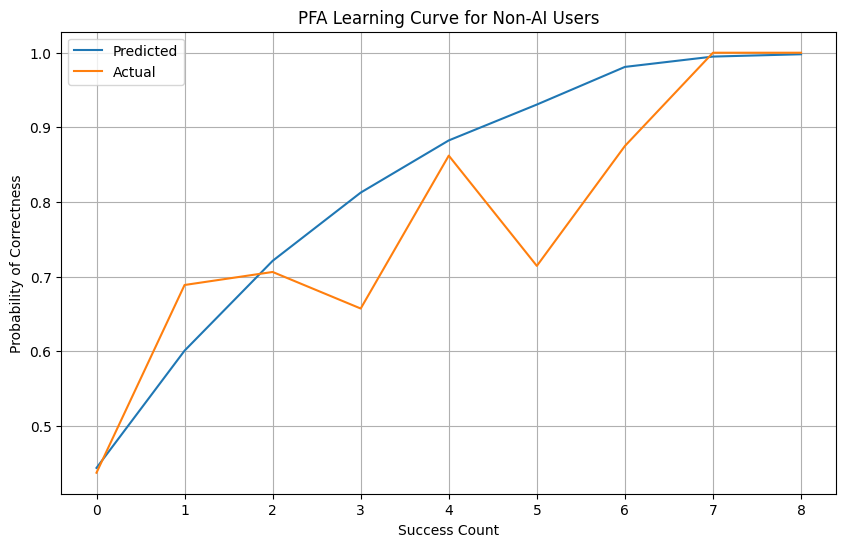

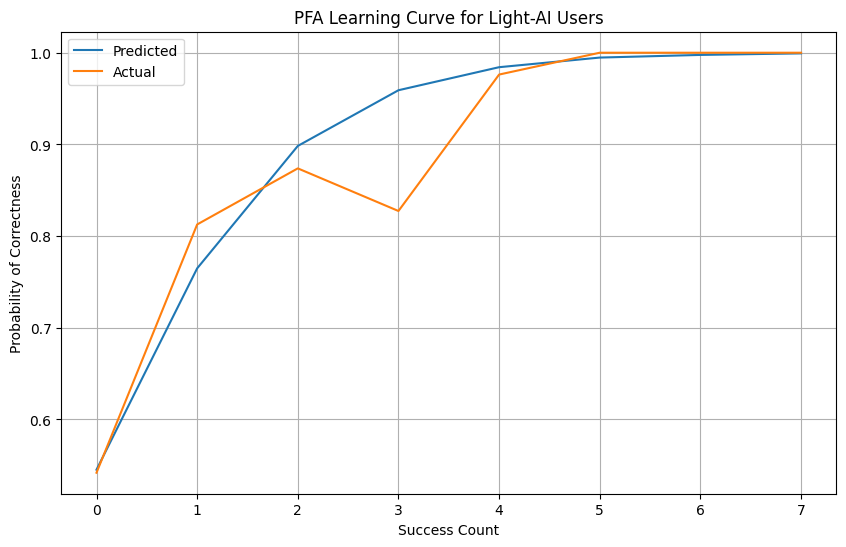

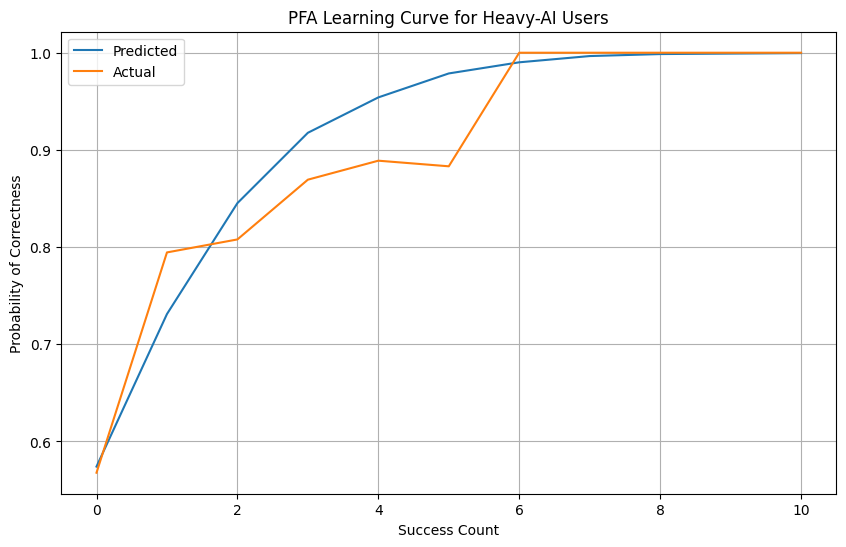

In [7]:
# PFA
from sklearn.linear_model import LogisticRegression

def prepare_pfa_features(df):
    """Prepare features for PFA modeling."""
    df = df.copy()
    df = df.sort_values(['user_id', 'timestamp'])
    df['success_count'] = 0
    df['failure_count'] = 0
    user_skill_groups = df.groupby(['user_id', 'skill_id'])
    for (user, skill), group in user_skill_groups:
        successes = 0
        failures = 0
        for idx in group.index:
            df.at[idx, 'success_count'] = successes
            df.at[idx, 'failure_count'] = failures
            if df.at[idx, 'correct'] == 1:
                successes += 1
            else:
                failures += 1
    if 'hint_used' not in df.columns:
        df['hint_used'] = 0
    if 'ai_message_count' not in df.columns:
        df['ai_message_count'] = 0

    feature_cols = ['success_count', 'failure_count', 'hint_used', 'ai_message_count']
    X = df[feature_cols]
    y = df['correct']
    return X, y

non_ai_users = all_data_categorical[all_data_categorical['ai_usage_category'] == 'non_ai_user']
light_ai_users = all_data_categorical[all_data_categorical['ai_usage_category'] == 'light_ai_user']
heavy_ai_users = all_data_categorical[all_data_categorical['ai_usage_category'] == 'heavy_ai_user']

non_ai_data_X, non_ai_data_y = prepare_pfa_features(non_ai_users)
light_ai_data_X, light_ai_data_y = prepare_pfa_features(light_ai_users)
heavy_ai_data_X, heavy_ai_data_y = prepare_pfa_features(heavy_ai_users)

# # All the students together
# X_pfa, y_pfa = prepare_pfa_features(all_data_categorical)

def train_pfa(X, y_true):
    pfa_model = LogisticRegression(max_iter=1000)
    pfa_model.fit(X, y_true)
    y_pred_probs = pfa_model.predict_proba(X)[:,1]
    return y_pred_probs

non_ai_data_y_pred = train_pfa(non_ai_data_X, non_ai_data_y)
light_ai_data_y_pred = train_pfa(light_ai_data_X, light_ai_data_y)
heavy_ai_data_y_pred = train_pfa(heavy_ai_data_X, heavy_ai_data_y)

# Plot 
import matplotlib.pyplot as plt

def plot_pfa_learning_curve(X, y_true, y_pred_probs, title="PFA Learning Curve"):
    df_plot = X.copy()
    df_plot['true'] = y_true
    df_plot['pred'] = y_pred_probs

    df_plot = df_plot[df_plot['success_count'] <= 10]  # limit to low success counts where we have data

    avg_pred = df_plot.groupby('success_count')['pred'].mean()
    avg_true = df_plot.groupby('success_count')['true'].mean()

    plt.figure(figsize=(10,6))
    plt.plot(avg_pred.index, avg_pred.values, label='Predicted')
    plt.plot(avg_true.index, avg_true.values, label='Actual')
    plt.title(title)
    plt.xlabel('Success Count')
    plt.ylabel('Probability of Correctness')
    plt.grid()
    plt.legend()
    plt.show()

plot_pfa_learning_curve(non_ai_data_X, non_ai_data_y, non_ai_data_y_pred, "PFA Learning Curve for Non-AI Users")
plot_pfa_learning_curve(light_ai_data_X, light_ai_data_y, light_ai_data_y_pred, "PFA Learning Curve for Light-AI Users")
plot_pfa_learning_curve(heavy_ai_data_X, heavy_ai_data_y, heavy_ai_data_y_pred, "PFA Learning Curve for Heavy-AI Users")

In [10]:
# DKT
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Masking
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# Step 1: Prepare DKT sequences
def prepare_dkt_sequences(df):
    df = df.copy()
    df = df.sort_values(['user_id', 'timestamp'])
    
    # Encode skills into integer indices
    from sklearn.preprocessing import LabelEncoder
    skill_encoder = LabelEncoder()
    df['skill_id_encoded'] = skill_encoder.fit_transform(df['skill_id'])

    sequences = []
    labels = []
    
    grouped = df.groupby('user_id')
    for user, group in grouped:
        skill_seq = group['skill_id_encoded'].tolist()
        correct_seq = group['correct'].tolist()
        combined_seq = [(skill, correct) for skill, correct in zip(skill_seq, correct_seq)]
        sequences.append(combined_seq)

    return sequences, skill_encoder

sequences, skill_encoder = prepare_dkt_sequences(all_data_categorical)

# Encode sequences
n_skills = len(skill_encoder.classes_)
max_seq_len = 100  # max number of interactions per user (can adjust)

X = []
y = []
for seq in sequences:
    input_seq = []
    output_seq = []
    for (skill, correct) in seq:
        input_id = skill + (correct * n_skills)  # clever trick: skill_id + n_skills if correct=1
        input_seq.append(input_id)
        output_seq.append(correct)
    X.append(input_seq)
    y.append(output_seq)

X_pad = pad_sequences(X, maxlen=max_seq_len, padding='post', value=2 * n_skills)  # pad with unknown ID
y_pad = pad_sequences(y, maxlen=max_seq_len, padding='post', value=-1)

# Step 2: Build DKT model
model = Sequential([
    Masking(mask_value=2 * n_skills, input_shape=(max_seq_len,)),
    LSTM(100, return_sequences=True),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam')

# Step 3: Prepare inputs/outputs
X_train, X_test, y_train, y_test = train_test_split(X_pad, y_pad, test_size=0.2, random_state=42)

# DKT expects one-hot inputs
from tensorflow.keras.utils import to_categorical

X_train_onehot = to_categorical(X_train, num_classes=2 * n_skills + 1)
X_test_onehot = to_categorical(X_test, num_classes=2 * n_skills + 1)

# Flatten outputs
y_train_flat = y_train.reshape((-1,))
y_test_flat = y_test.reshape((-1,))
mask_train = y_train_flat != -1
mask_test = y_test_flat != -1

# Train only on valid steps
history = model.fit(X_train_onehot.reshape((-1, max_seq_len, 2 * n_skills + 1)),
                    y_train_flat[mask_train],
                    epochs=10,
                    batch_size=64,
                    validation_data=(X_test_onehot.reshape((-1, max_seq_len, 2 * n_skills + 1)), y_test_flat[mask_test]))

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
# EXTRA PLOTS JUST FOR COMPARISON

In [14]:
# iBKT/individualized-BKT

# 1. First, train a normal BKT model
def train_bkt_basic(df):
    model = Model(seed=42)
    model.fit(data=df)
    return model

# 2. Then, compute per-user average residuals and add a user bias
def train_ibkt(df):
    bkt_model = train_bkt_basic(df)
    preds = bkt_model.predict(data=df)
    df['predicted'] = preds['correct_predictions']
    df['residual'] = df['correct'] - df['predicted']

    user_bias = df.groupby('user_id')['residual'].mean().to_dict()

    return bkt_model, user_bias

# 3. Prediction function
def predict_ibkt(model, user_bias, df):
    preds = model.predict(data=df)
    preds['correct_predictions_ibkt'] = preds['correct_predictions']

    # Add user bias
    preds['correct_predictions_ibkt'] += preds['user_id'].map(user_bias).fillna(0)

    # Clip predictions between [0,1]
    preds['correct_predictions_ibkt'] = preds['correct_predictions_ibkt'].clip(0, 1)

    return preds

# Example usage:
# Prepare data
def prepare_pyBKT_format(df):
    df = df[['user_id', 'skill_id', 'correct']].copy()
    df.columns = ['user_id', 'skill_name', 'correct']
    return df

# Prepare your dataset
filtered_data = all_data_categorical.copy()
filtered_data_simple = prepare_pyBKT_format(filtered_data)

# Train
bkt_model, user_bias = train_ibkt(filtered_data_simple)

# Predict
preds_ibkt = predict_ibkt(bkt_model, user_bias, filtered_data_simple)

/tmp/ipykernel_118/2350771811.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_pred = df_plot.groupby('history_bin')['pred'].mean()
/tmp/ipykernel_118/2350771811.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_true = df_plot.groupby('history_bin')['true'].mean()


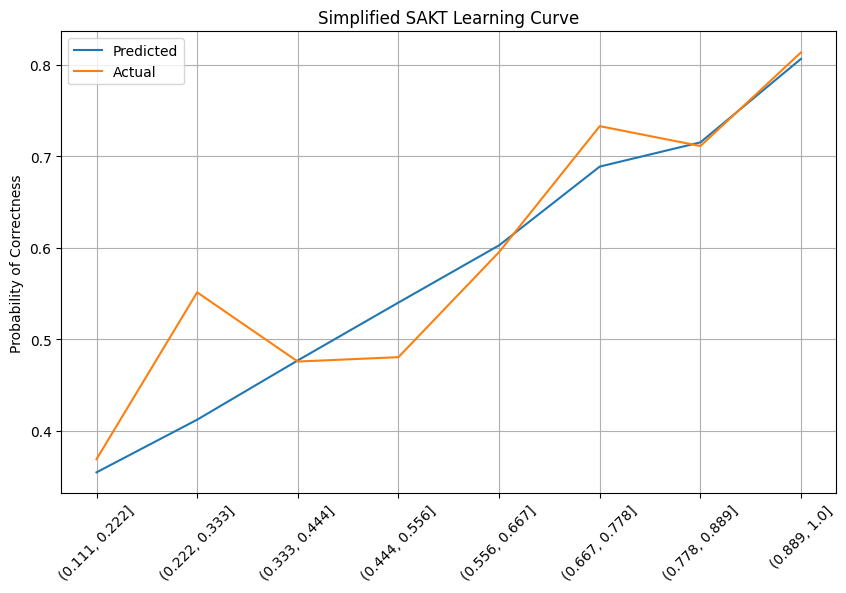

In [12]:
#Mini-SAKT
from sklearn.linear_model import LogisticRegression

# 1. Prepare interaction history
def prepare_sakt_features(df, window_size=5):
    df = df.copy()
    df = df.sort_values(['user_id', 'timestamp'])

    df['history_correct_mean'] = 0.5  # initialize

    user_groups = df.groupby('user_id')
    for user, group in user_groups:
        correct_history = []
        for idx in group.index:
            if len(correct_history) == 0:
                df.at[idx, 'history_correct_mean'] = 0.5  # no history
            else:
                df.at[idx, 'history_correct_mean'] = np.mean(correct_history[-window_size:])
            correct_history.append(df.at[idx, 'correct'])

    features = df[['history_correct_mean']]
    labels = df['correct']
    return features, labels

# Prepare features
X_sakt, y_sakt = prepare_sakt_features(all_data_categorical)

# 2. Train logistic regression on history
sakt_model = LogisticRegression(max_iter=1000)
sakt_model.fit(X_sakt, y_sakt)

# 3. Predict
y_pred_probs_sakt = sakt_model.predict_proba(X_sakt)[:,1]

# 4. Plot (optional)
import matplotlib.pyplot as plt

def plot_sakt_learning_curve(X, y_true, y_pred_probs):
    df_plot = X.copy()
    df_plot['true'] = y_true
    df_plot['pred'] = y_pred_probs

    bins = np.linspace(0, 1, 10)
    df_plot['history_bin'] = pd.cut(df_plot['history_correct_mean'], bins)

    avg_pred = df_plot.groupby('history_bin')['pred'].mean()
    avg_true = df_plot.groupby('history_bin')['true'].mean()

    plt.figure(figsize=(10,6))
    plt.plot(avg_pred.index.astype(str), avg_pred.values, label='Predicted')
    plt.plot(avg_true.index.astype(str), avg_true.values, label='Actual')
    plt.xticks(rotation=45)
    plt.title("Simplified SAKT Learning Curve")
    plt.ylabel('Probability of Correctness')
    plt.grid()
    plt.legend()
    plt.show()

plot_sakt_learning_curve(X_sakt, y_sakt, y_pred_probs_sakt)

## Task 3: Model Evaluation
In this task, you will use metrics to evaluate your model.

In [ ]:
# Your code for model evaluation goes here

*Your discussion/interpretation about your model's behavior goes here*

## Task 4: Team Reflection
Please describe the contributions of each team member to Milestone 4. Reflect on how you worked as team: what went well, what can be improved for the next milestone?

*Your discussion about team responsibilities goes here*